In [1]:
import numpy as np

# 加载数据
data = np.load('toy_mnist_2024.npz')
X, y = data['X'], data['y']
print(X.shape)
# 将数据转换为浮点型并归一化
X = X.astype(np.float32) / 255.0

(1000, 28, 28)


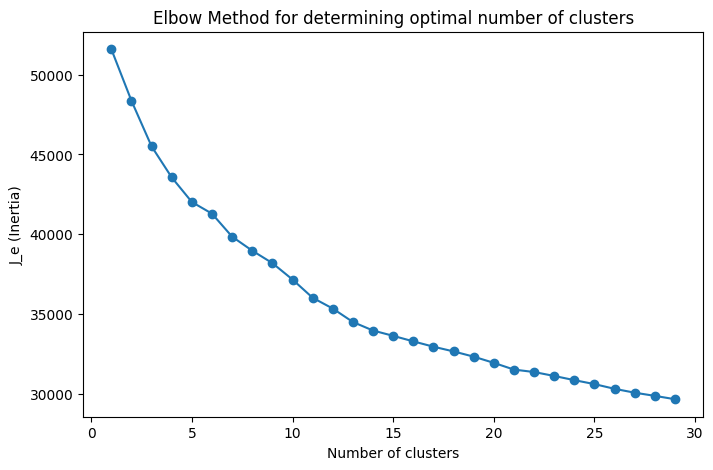

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# 将图像展平为 1D 向量
X_flattened = X.reshape(X.shape[0], -1)  # 将每个 28x28 的图像展平为一维向量

# 计算不同聚类数的 J_e 值
inertia = []
cluster_range = range(1, 30)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_flattened)
    inertia.append(kmeans.inertia_)

# 绘制 J_e 相对于聚类数的关系图
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('J_e (Inertia)')
plt.title('Elbow Method for determining optimal number of clusters')
plt.show()


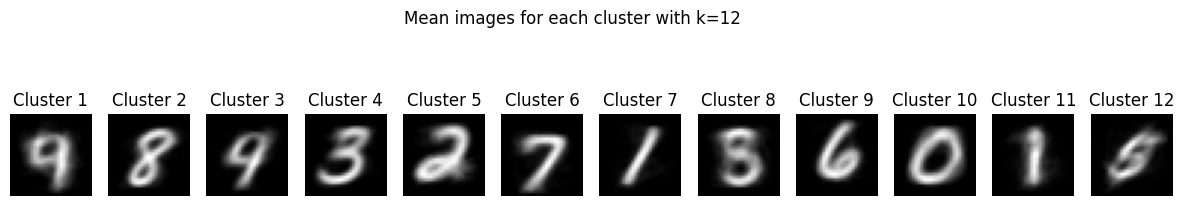

In [3]:
# 使用最佳聚类数进行 KMeans 聚类
optimal_k = 12 
kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X_flattened)

# 获取聚类中心并将其重新 reshape 为 28x28 的图像
cluster_centers = kmeans.cluster_centers_.reshape(optimal_k, 28, 28)

# 可视化每个聚类的均值图像
fig, axes = plt.subplots(1, optimal_k, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(cluster_centers[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i + 1}')
plt.suptitle(f'Mean images for each cluster with k={optimal_k}')
plt.show()


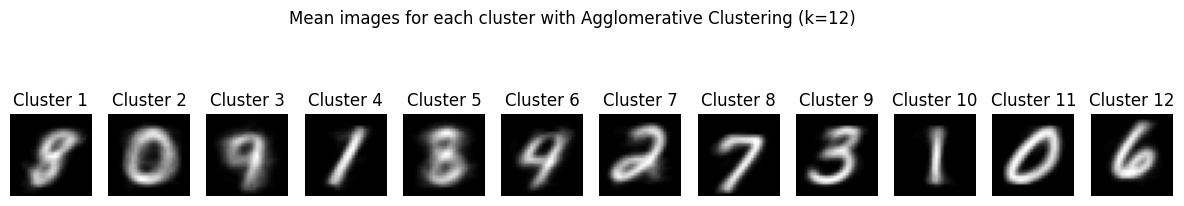

In [4]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt


# 使用 AgglomerativeClustering 进行分级聚类
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit(X_flattened)
agglo_labels = agglo.labels_

# 可视化分级聚类的均值图像
cluster_means = []
for i in range(optimal_k):
    cluster_mean = X[agglo_labels == i].mean(axis=0)  # 计算每个聚类的均值
    cluster_means.append(cluster_mean)

# 绘制每个聚类的均值图像
fig, axes = plt.subplots(1, optimal_k, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(cluster_means[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i + 1}')
plt.suptitle(f'Mean images for each cluster with Agglomerative Clustering (k={optimal_k})')
plt.show()


In [5]:
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering

# 使用 KMeans 聚类结果的 NMI
kmeans_labels = kmeans.labels_
nmi_kmeans = normalized_mutual_info_score(y.argmax(axis=1), kmeans_labels)

# 使用分级聚类算法
agglo_labels = agglo.labels_
nmi_agglo = normalized_mutual_info_score(y.argmax(axis=1), agglo_labels)

print(f'KMeans NMI: {nmi_kmeans:.4f}')
print(f'Agglomerative Clustering NMI: {nmi_agglo:.4f}')

KMeans NMI: 0.5197
Agglomerative Clustering NMI: 0.5372


K=2, KMeans NMI: 0.1706, Agglomerative Clustering NMI: 0.2163
K=3, KMeans NMI: 0.3080, Agglomerative Clustering NMI: 0.3717
K=4, KMeans NMI: 0.3992, Agglomerative Clustering NMI: 0.4220
K=5, KMeans NMI: 0.4643, Agglomerative Clustering NMI: 0.4611
K=6, KMeans NMI: 0.3917, Agglomerative Clustering NMI: 0.5128
K=7, KMeans NMI: 0.4064, Agglomerative Clustering NMI: 0.5383
K=8, KMeans NMI: 0.3679, Agglomerative Clustering NMI: 0.5505
K=9, KMeans NMI: 0.3972, Agglomerative Clustering NMI: 0.5518
K=10, KMeans NMI: 0.4563, Agglomerative Clustering NMI: 0.5433
K=11, KMeans NMI: 0.4983, Agglomerative Clustering NMI: 0.5397
K=12, KMeans NMI: 0.5197, Agglomerative Clustering NMI: 0.5372
K=13, KMeans NMI: 0.5231, Agglomerative Clustering NMI: 0.5559
K=14, KMeans NMI: 0.5328, Agglomerative Clustering NMI: 0.5570
K=15, KMeans NMI: 0.5410, Agglomerative Clustering NMI: 0.5562
K=16, KMeans NMI: 0.5450, Agglomerative Clustering NMI: 0.5818
K=17, KMeans NMI: 0.5576, Agglomerative Clustering NMI: 0.5763


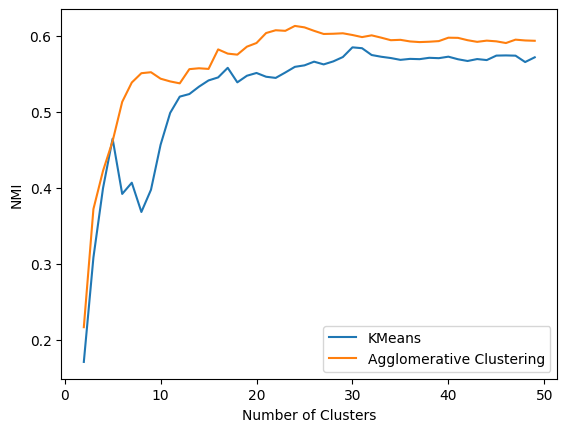

In [13]:
nmi_kmeans_list = []
nmi_agglo_list = []
k_list = range(2,50)
for optimal_k in k_list:
    kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X_flattened)
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit(X_flattened)
    # 使用 KMeans 聚类结果的 NMI
    kmeans_labels = kmeans.labels_
    nmi_kmeans = normalized_mutual_info_score(y.argmax(axis=1), kmeans_labels)
    nmi_kmeans_list.append(nmi_kmeans)
    # 使用分级聚类算法
    agglo_labels = agglo.labels_
    nmi_agglo = normalized_mutual_info_score(y.argmax(axis=1), agglo_labels)
    nmi_agglo_list.append(nmi_agglo)
    print(f'K={optimal_k}, KMeans NMI: {nmi_kmeans:.4f}, Agglomerative Clustering NMI: {nmi_agglo:.4f}')

plt.plot(k_list, nmi_kmeans_list, label='KMeans')
plt.plot(k_list, nmi_agglo_list, label='Agglomerative Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('NMI')
plt.legend()

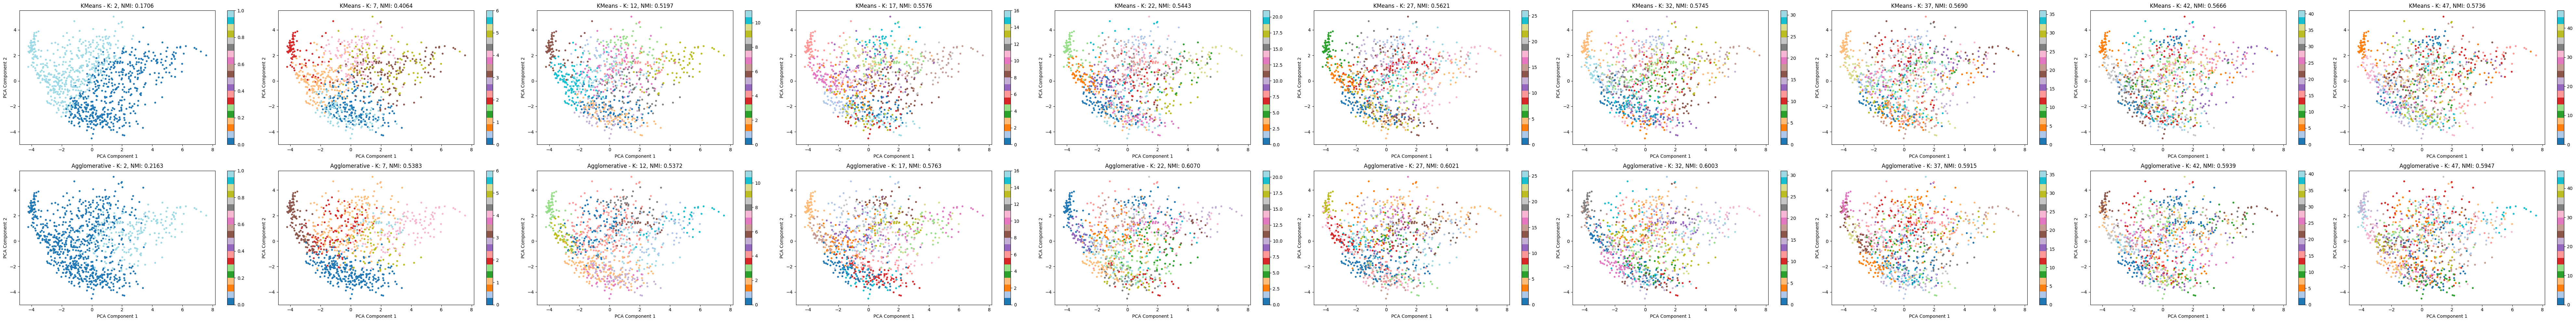

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import normalized_mutual_info_score

# 假设 X_flattened 和 y 已经定义
k_list = range(2, 50, 5)

# 使用 PCA 将数据降维到 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flattened)

# 初始化 NMI 记录列表
nmi_kmeans_list = []
nmi_agglo_list = []

# 创建一个 2 行 len(k_list) 列的子图
fig, axes = plt.subplots(2, len(k_list), figsize=(8 * len(k_list), 10))

for i, optimal_k in enumerate(k_list):
    # KMeans 聚类
    kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X_flattened)
    kmeans_labels = kmeans.labels_
    nmi_kmeans = normalized_mutual_info_score(y.argmax(axis=1), kmeans_labels)
    nmi_kmeans_list.append(nmi_kmeans)
    
    # 层次聚类 (Agglomerative Clustering)
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit(X_flattened)
    agglo_labels = agglo.labels_
    nmi_agglo = normalized_mutual_info_score(y.argmax(axis=1), agglo_labels)
    nmi_agglo_list.append(nmi_agglo)
    
    # 绘制 KMeans 聚类结果
    scatter_kmeans = axes[0, i].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab20', s=10)
    fig.colorbar(scatter_kmeans, ax=axes[0, i])
    axes[0, i].set_title(f'KMeans - K: {optimal_k}, NMI: {nmi_kmeans:.4f}')
    axes[0, i].set_xlabel('PCA Component 1')
    axes[0, i].set_ylabel('PCA Component 2')
    
    # 绘制 Agglomerative Clustering 聚类结果
    scatter_agglo = axes[1, i].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='tab20', s=10)
    fig.colorbar(scatter_agglo, ax=axes[1, i])
    axes[1, i].set_title(f'Agglomerative - K: {optimal_k}, NMI: {nmi_agglo:.4f}')
    axes[1, i].set_xlabel('PCA Component 1')
    axes[1, i].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()



/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_1703/1677117738.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 8000x1000 with 40 Axes> than <Figure size 6400x1000 with 5 Axes> which fig.colorbar is called on.
  fig.colorbar(scatter_kmeans, ax=axes[i])
/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_1703/1677117738.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 8000x1000 with 40 Axes> than <Figure size 6400x1000 with 6 Axes> which fig.colorbar is called on.
  fig.colorbar(scatter_kmeans, ax=axes[i])
/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_1703/1677117738.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 8000x1000 with 40 Axes> than <Figure size 6400x1000 with 7 Axes> which fig.colorbar is called on.
  fig.colorbar(scatter_kmeans, ax=axes[i])
/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_1703/1677117738.py:23: UserWarning: Adding colorbar to a different Figure <Figur

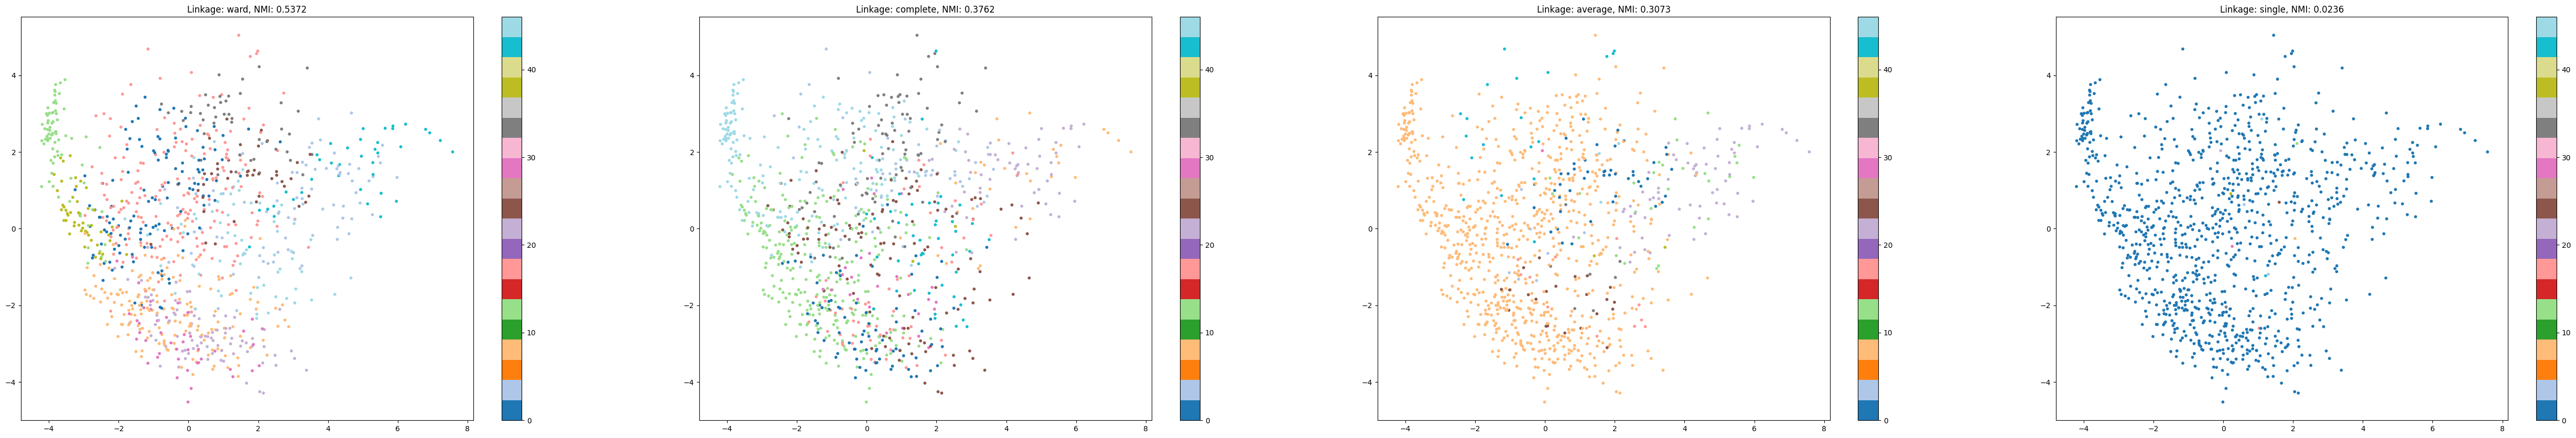

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import normalized_mutual_info_score

# 假设 X_flattened 和 y 已经定义并包含数据
optimal_k =12

# 使用 PCA 将数据降维到 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flattened)
fig, axes = plt.subplots(1, 4, figsize=(16 * 4, 10))
# 不同 linkage 策略的聚类结果
for i,linkage in enumerate(['ward', 'complete', 'average', 'single']):
    # 进行聚类
    agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage=linkage).fit(X_flattened)
    agglo_labels = agglo.labels_
    nmi_agglo = normalized_mutual_info_score(y.argmax(axis=1), agglo_labels)
    
    # 绘制聚类结果
    # plt.figure(figsize=(8, 6))
    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='tab20', s=10)
    fig.colorbar(scatter_kmeans, ax=axes[i])
    axes[i].set_title(f'Linkage: {linkage}, NMI: {nmi_agglo:.4f}')
    # axes[i].xlabel('PCA Component 1')
    # axes[i].ylabel('PCA Component 2')
plt.show()

